In [33]:
import geopandas as gpd
import geodatasets
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [20]:
geodatasets.data.flatten().keys()

dict_keys(['geoda.airbnb', 'geoda.atlanta', 'geoda.cars', 'geoda.charleston1', 'geoda.charleston2', 'geoda.chicago_health', 'geoda.chicago_commpop', 'geoda.chile_labor', 'geoda.cincinnati', 'geoda.cleveland', 'geoda.grid100', 'geoda.groceries', 'geoda.guerry', 'geoda.health', 'geoda.health_indicators', 'geoda.hickory1', 'geoda.hickory2', 'geoda.home_sales', 'geoda.houston', 'geoda.juvenile', 'geoda.lansing1', 'geoda.lansing2', 'geoda.lasrosas', 'geoda.liquor_stores', 'geoda.malaria', 'geoda.milwaukee1', 'geoda.milwaukee2', 'geoda.ncovr', 'geoda.natregimes', 'geoda.ndvi', 'geoda.nepal', 'geoda.nyc', 'geoda.nyc_earnings', 'geoda.nyc_education', 'geoda.nyc_neighborhoods', 'geoda.orlando1', 'geoda.orlando2', 'geoda.oz9799', 'geoda.phoenix_acs', 'geoda.police', 'geoda.sacramento1', 'geoda.sacramento2', 'geoda.savannah1', 'geoda.savannah2', 'geoda.seattle1', 'geoda.seattle2', 'geoda.sids', 'geoda.sids2', 'geoda.south', 'geoda.spirals', 'geoda.stlouis', 'geoda.tampa1', 'geoda.us_sdoh', 'ny.bb

In [21]:
geodatasets.data.geoda.nyc_neighborhoods


{'url': 'https://geodacenter.github.io/data-and-lab//data/nycnhood_acs.zip',
 'license': 'NA',
 'attribution': 'Center for Spatial Data Science, University of Chicago',
 'name': 'geoda.nyc_neighborhoods',
 'description': 'Demographics for New York City neighborhoods',
 'geometry_type': 'Polygon',
 'nrows': 195,
 'ncols': 99,
 'details': 'https://geodacenter.github.io/data-and-lab//NYC-Nhood-ACS-2008-12/',
 'hash': 'aeb75fc5c95fae1088093827fca69928cee3ad27039441bb35c03013d2ee403f',
 'filename': 'nycnhood_acs.zip'}

   UEMPRATE  cartodb_id  borocode  withssi  withsocial  withpubass  \
0  0.095785           1         3      652        5067         277   
1  0.090011           2         3     2089        7132        1016   
2  0.130393           3         3     3231        8847        2891   
3  0.086633           4         3     1103        3508         553   
4  0.099184           5         4      326        2229         132   

   struggling  profession  popunemplo  poptot  ...  boroname      popdty  \
0        6421         889        2225   48351  ...  Brooklyn  497498.701   
1       10981        1075        2652   61584  ...  Brooklyn  589296.926   
2       21235         712        6483  100130  ...  Brooklyn  1506628.84   
3        7188         475        1709   33155  ...  Brooklyn  468975.876   
4        5307         187        1276   24199  ...    Queens  125384.135   

   ntacode  medianinco  medianagem  medianagef  medianage            HHsize  \
0     BK45     1520979       663.3       77

<Axes: >

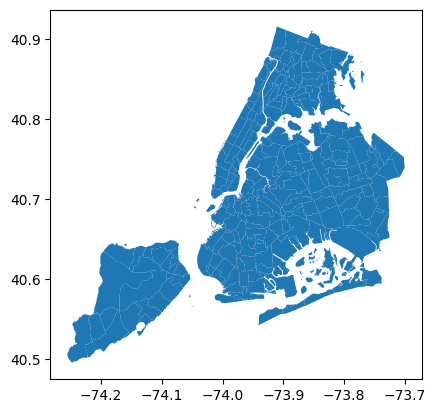

In [22]:
url = geodatasets.get_url('geoda.nyc_neighborhoods')
df = gpd.read_file(url)
print(df.head())
df.plot()

POLYGON ((-73.72586264182358 40.68324108094787, -73.72590660060472 40.682656605126624, -73.7258236766503 40.68163575061283, -73.72575419060884 40.68094591409301, -73.72568736760775 40.68025045486142, -73.72563005119694 40.67958795128393, -73.72601116023363 40.67807833782763, -73.72619806195746 40.67738088972973, -73.72654317253543 40.67648672961882, -73.72714134203693 40.6750958758445, -73.72744080458703 40.67442874135086, -73.72753358420485 40.67421386411909, -73.72755616356449 40.67416158819153, -73.72753500302302 40.67393028479496, -73.7277941488049 40.67145467646652, -73.72788358626993 40.670796436623675, -73.72792572850256 40.670097148020126, -73.72799989246542 40.669405044641266, -73.72817255589534 40.668717428836025, -73.72821266699543 40.66831295034006, -73.72826385203372 40.66807287563196, -73.72822217040637 40.66731363955721, -73.72826620785708 40.66660628634406, -73.72827272254972 40.66642959208359, -73.72821911958363 40.66591458445316, -73.72814252038624 40.66551437427628, 

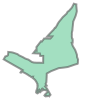

In [23]:
#check out the Geometry column
print(df['geometry'].iloc[12])
df['geometry'].iloc[12]

<Axes: >

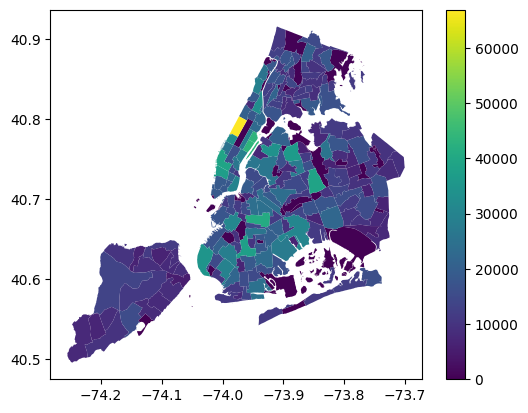

In [24]:
df.plot(column = 'households', legend = True)

<Axes: >

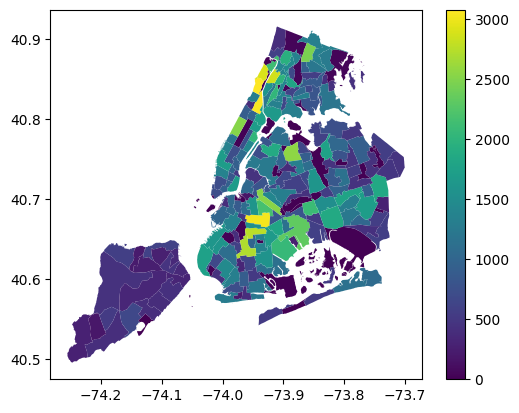

In [25]:
df.plot(column = 'femaleunem', legend = True)

<Axes: >

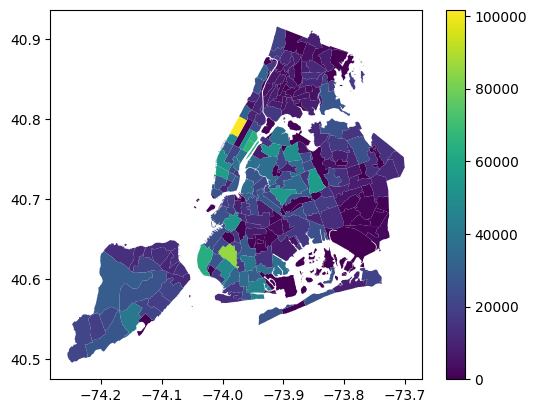

In [26]:
df.plot(column = 'european', legend = True)

<Axes: >

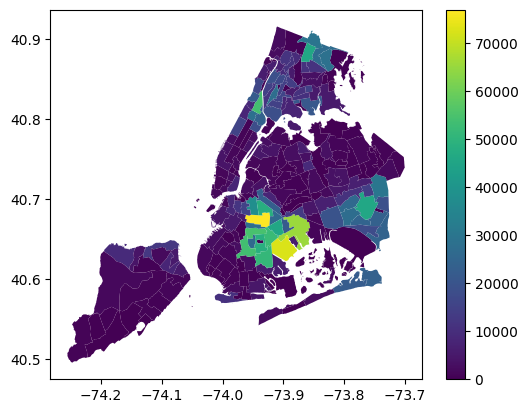

In [27]:
df.plot(column = 'african', legend = True)

<Axes: >

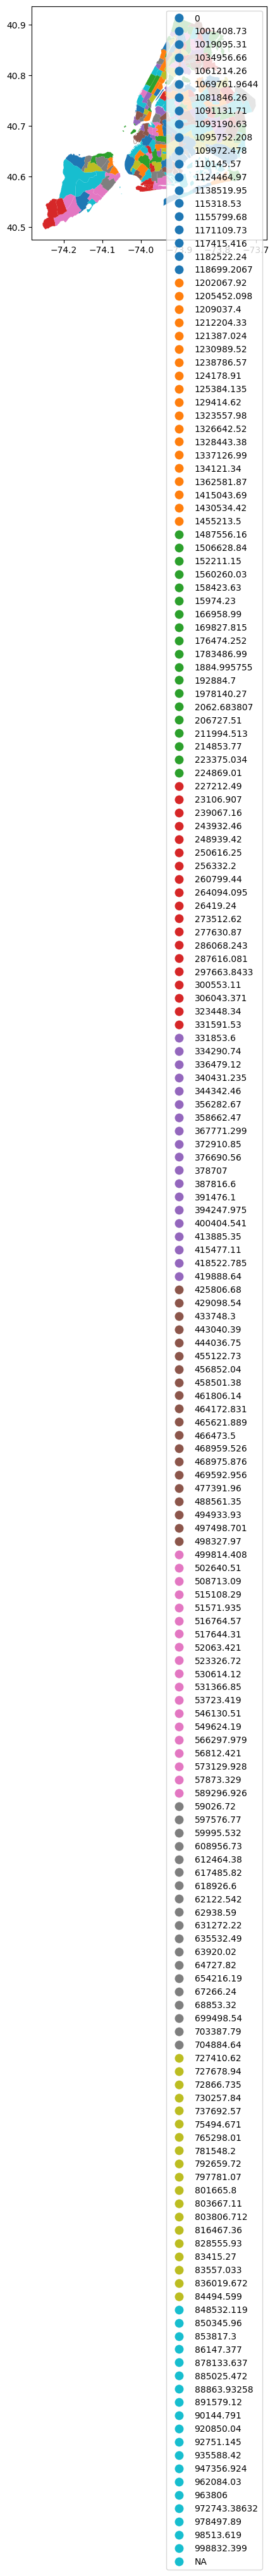

In [28]:
df.plot(column = 'popdty', legend = True)

<Axes: >

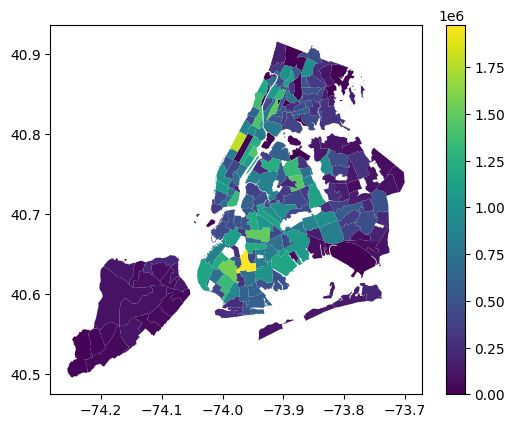

In [29]:
df['popdty'] = pd.to_numeric(df['popdty'], errors='coerce')  # Convert to float
df['popdty'] = df['popdty'].round(0)  # Round after conversion
df.plot(column='popdty', legend=True)

<Axes: >

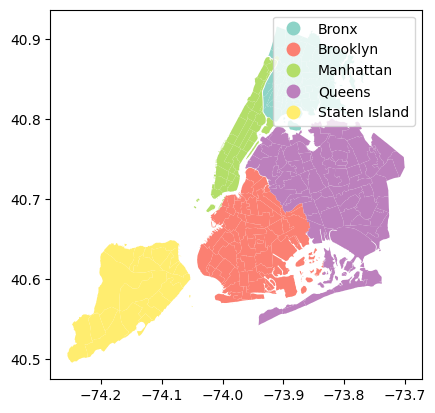

In [30]:
df.plot(column='boroname', cmap='Set3', legend=True)


<Axes: >

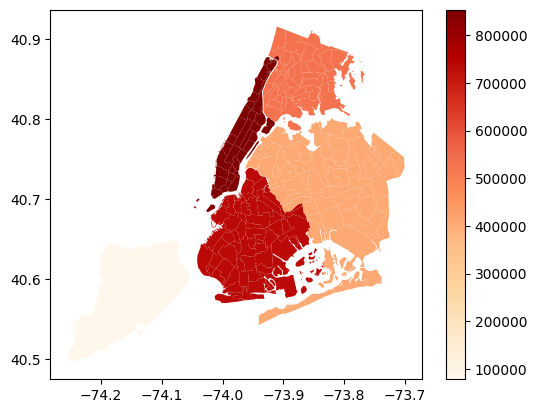

In [31]:
borough_avg = df.groupby('boroname')['popdty'].mean().to_dict()
df['borough_popdty'] = df['boroname'].map(borough_avg)
df.plot(column='borough_popdty', cmap='OrRd', legend=True, edgecolor=None)

[Text(0.5, 1.0, 'Average Population Density by Borough')]

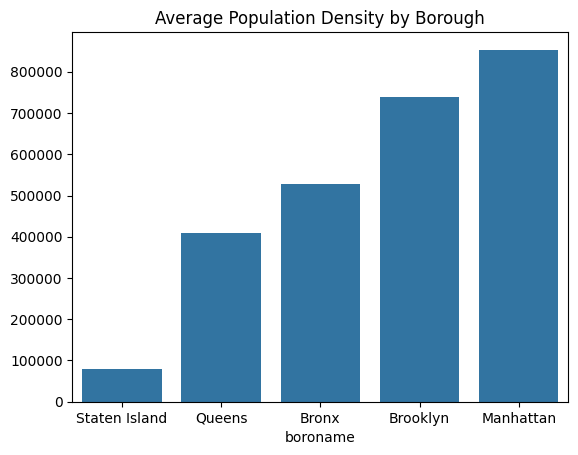

In [32]:
sns.barplot(
    x=df.groupby('boroname')['popdty'].mean().sort_values().index,
    y=df.groupby('boroname')['popdty'].mean().sort_values().values
).set(title="Average Population Density by Borough")

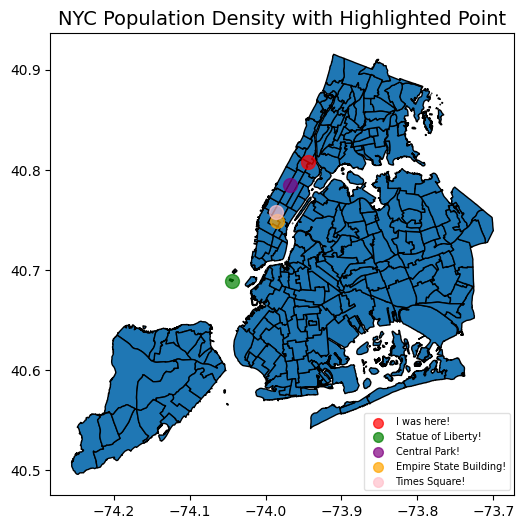

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))
df.plot( cmap=None, legend=True, edgecolor='black', ax=ax)
ax.scatter(-73.9442, 40.8075, color='red', s=100, label="I was here!", alpha=0.7)
ax.scatter(-74.0445, 40.6892, color='green', s=100, label="Statue of Liberty!", alpha=0.7)
ax.scatter(-73.9683, 40.7851, color='purple', s=100, label="Central Park!", alpha=0.7)
ax.scatter(-73.985428, 40.748817, color='orange', s=100, label="Empire State Building!", alpha=0.7)
ax.scatter(-73.9857, 40.7580, color='pink', s=100, label="Times Square!", alpha=0.7)
ax.set_title("NYC Population Density with Highlighted Point", fontsize=14)
ax.legend(
    loc='lower right',   # move out of the way
    fontsize=7,          # smaller text
    markerscale=0.7,     # smaller marker icons
    framealpha=0.6       # semi-transparent background
)
plt.show()